=== LIMA DATA PERTAMA ===
  TransactionID AccountID  TransactionAmount PreviousTransactionDate  \
0      TX000001   AC00128              14.09     2023-04-11 16:29:14   
1      TX000002   AC00455             376.24     2023-06-27 16:44:19   
2      TX000003   AC00019             126.29     2023-07-10 18:16:08   
3      TX000004   AC00070             184.50     2023-05-05 16:32:11   
4      TX000005   AC00411              13.45     2023-10-16 17:51:24   

  TransactionType   Location DeviceID      IP Address MerchantID Channel  \
0           Debit  San Diego  D000380  162.198.218.92       M015     ATM   
1           Debit    Houston  D000051     13.149.61.4       M052     ATM   
2           Debit       Mesa  D000235  215.97.143.157       M009  Online   
3           Debit    Raleigh  D000187  200.13.225.150       M002  Online   
4          Credit    Atlanta  D000308    65.164.3.100       M091  Online   

   CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
0         7

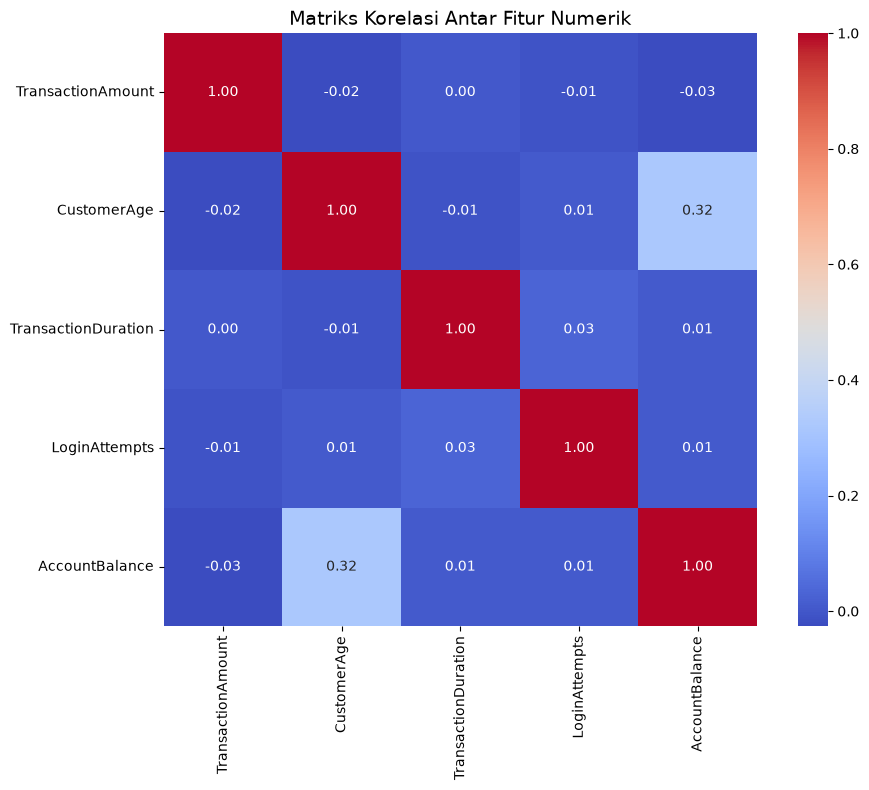

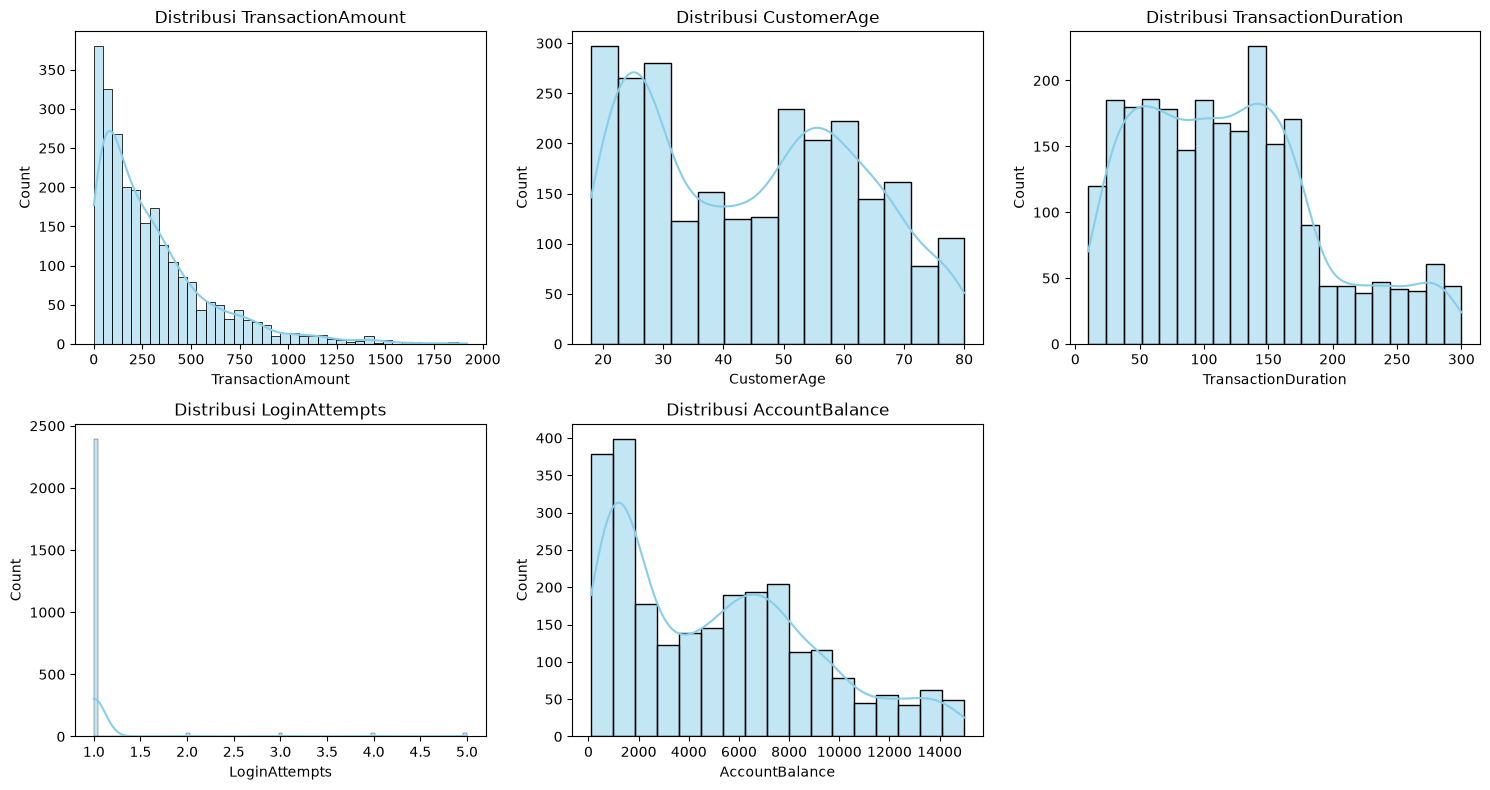


Jumlah Missing Values:
TransactionID              29
AccountID                  21
TransactionAmount          26
PreviousTransactionDate    28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
TransactionDate            24
dtype: int64

Last Checking (Columns List):
['TransactionAmount', 'TransactionType', 'Location', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']

=== DATA SETELAH PREPROCESSING ===
       TransactionAmount  TransactionType      Location      Channel  \
count       1.501000e+03           1501.0  1.501000e+03  1501.000000   
mean       -4.733796e-17              0.0 -8.520832e-17     0.000000   
std         1.000333e+00              0.0

C:\Users\MyBook Prime\AppData\Local\Temp\ipykernel_21520\31792780.py:61: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=['object']).columns


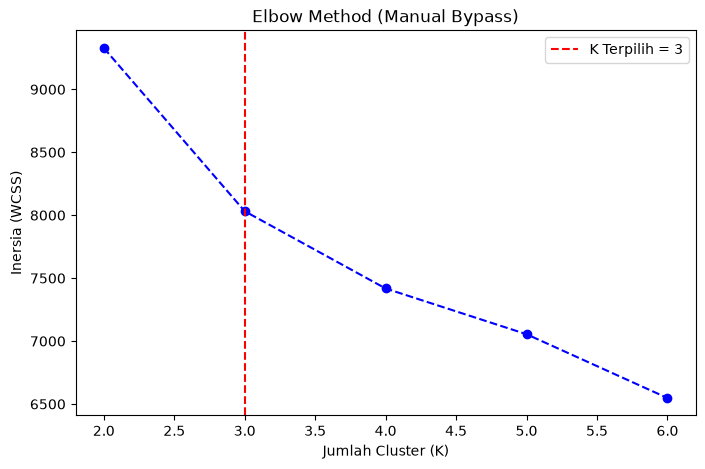


Silhouette Score: 0.1927


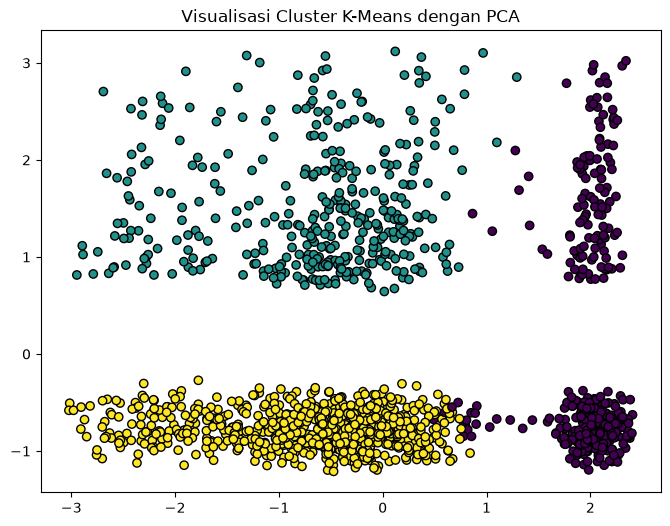


=== STATISTIK DESKRIPTIF DATA INVERSE PER CLUSTER ===


TypeError: dtype 'str' does not support operation 'mean'

In [2]:
# ==========================================
# GABUNGAN KODE UTUH NOTEBOOK CLUSTERING
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

# 1. Load data dari berkas Excel asli Anda
df = pd.read_excel('bank_transactions_data_edited.xlsx', engine='openpyxl')

print("=== LIMA DATA PERTAMA ===")
print(df.head())

print("\n=== INFORMASI DATASET ===")
df.info()

print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe(include='all'))

# Matriks korelasi untuk fitur numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Visualisasi Korelasi (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Matriks Korelasi Antar Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

# Visualisasi Histogram Otomatis
n_num_cols = len(numeric_cols)
fig, axes = plt.subplots(nrows=(n_num_cols + 2) // 3, ncols=3, figsize=(15, 4 * ((n_num_cols + 2) // 3)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribusi {col}')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Pembersihan Data Hilang dan Duplikat
print("\nJumlah Missing Values:")
print(df.isnull().sum())
df_clean = df.dropna().drop_duplicates()

# Drop kolom identitas dan tanggal
columns_to_drop = ['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID', 'TransactionDate', 'PreviousTransactionDate']
existing_drop_cols = [col for col in columns_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_drop_cols)

# Feature Encoding untuk Fitur Kategorikal
categorical_cols = df_clean.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

print("\nLast Checking (Columns List):")
print(df_clean.columns.tolist())

# Handling Outlier Data (Metode Drop IQR)
numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns
df_filtered = df_clean.copy()
for col in numeric_cols_clean:
    Q1 = df_filtered[col].quantile(0.25)
    Q3 = df_filtered[col].quantile(0.75)
    IQR = Q3 - Q1
    df_filtered = df_filtered[(df_filtered[col] >= (Q1 - 1.5 * IQR)) & (df_filtered[col] <= (Q3 + 1.5 * IQR))]
df_clean = df_filtered.copy()

# Feature Scaling
scaler = StandardScaler()
features_to_scale = [col for col in numeric_cols_clean if col in df_clean.columns]
if features_to_scale:
    df_clean[features_to_scale] = scaler.fit_transform(df_clean[features_to_scale])

# Binning Data Numerik
if features_to_scale:
    target_bin = features_to_scale[0]
    df_clean[f'{target_bin}_Group'] = pd.qcut(df_clean[target_bin], q=3, labels=['Low', 'Medium', 'High']).astype(str)
    df_clean[f'{target_bin}_Group'] = LabelEncoder().fit_transform(df_clean[f'{target_bin}_Group'])

print("\n=== DATA SETELAH PREPROCESSING ===")
print(df_clean.describe())

# Elbow Method Alternatif (Murni Scikit-Learn + Matplotlib)
X_cluster = df_clean.copy()
wcss = []
k_range = range(2, 7)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method (Manual Bypass)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (WCSS)')
optimal_k = 3
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'K Terpilih = {optimal_k}')
plt.legend()
plt.show()

# Membangun Model K-Means Clustering
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans_model.fit_predict(X_cluster)
joblib.dump(kmeans_model, 'model_clustering.h5')

print(f"\nSilhouette Score: {silhouette_score(X_cluster, cluster_labels):.4f}")

# Reduksi Dimensi dengan PCA & Visualisasi
pca_reducer = PCA(n_components=2, random_state=42)
X_pca = pca_reducer.fit_transform(X_cluster)
joblib.dump(pca_reducer, "PCA_model_clustering.h5")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', edgecolors='k')
plt.title('Visualisasi Cluster K-Means dengan PCA')
plt.show()

# Tambahkan label Target
df_clean['Target'] = cluster_labels
df_clean.to_csv('data_clustering.csv', index=False)

# Proses Invers Data ke Skala Asli
df_inverse = df_clean.copy()
if features_to_scale:
    df_inverse[features_to_scale] = scaler.inverse_transform(df_clean[features_to_scale])
for col in categorical_cols:
    if col in label_encoders:
        df_inverse[col] = label_encoders[col].inverse_transform(df_inverse[col].astype(int))

print("\n=== STATISTIK DESKRIPTIF DATA INVERSE PER CLUSTER ===")
print(df_inverse.groupby('Target')[features_to_scale].agg(['mean', 'min', 'max']))

# Ekspor Akhir dokumen pendukung
df_inverse.to_csv('data_clustering_inverse.csv', index=False)
print("\n[SUKSES] Semua file model .h5 dan berkas .csv berhasil diperbarui!")